# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [2]:
# importar librerías
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')
usage = pd.read_csv('/datasets/usage.csv')

In [4]:
plans.head(5)

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [5]:
users.head

<bound method NDFrame.head of       user_id first_name last_name  age      city  \
0       10000     Carlos    Garcia   38  Medellín   
1       10001      Mateo    Torres   53         ?   
2       10002      Sofia   Ramirez   57      CDMX   
3       10003      Mateo   Ramirez   69    Bogotá   
4       10004      Mateo    Torres   63       GDL   
...       ...        ...       ...  ...       ...   
3995    13995        Ana     Lopez   60  Medellín   
3996    13996     Carlos   Ramirez   24  Medellín   
3997    13997        Ana     Lopez   58    Bogotá   
3998    13998    Mariana     Lopez   57    Bogotá   
3999    13999        Ana     Lopez   20    Bogotá   

                           reg_date     plan churn_date  
0     2022-01-01 00:00:00.000000000   Basico        NaN  
1     2022-01-01 06:34:17.914478619   Basico        NaN  
2     2022-01-01 13:08:35.828957239   Basico        NaN  
3     2022-01-01 19:42:53.743435858  Premium        NaN  
4     2022-01-02 02:17:11.657914478   Basic

In [6]:
usage.head

<bound method NDFrame.head of           id  user_id  type                           date  duration  length
0          1    10332  call  2024-01-01 00:00:00.000000000      0.09     NaN
1          2    11458  text  2024-01-01 00:06:30.969774244       NaN    39.0
2          3    11777  text  2024-01-01 00:13:01.939548488       NaN    36.0
3          4    10682  call  2024-01-01 00:19:32.909322733      1.53     NaN
4          5    12742  call  2024-01-01 00:26:03.879096977      4.84     NaN
...      ...      ...   ...                            ...       ...     ...
39995  39996    13497  call  2024-06-29 23:33:56.120903022      5.75     NaN
39996  39997    10941  call  2024-06-29 23:40:27.090677266      3.06     NaN
39997  39998    13038  call  2024-06-29 23:46:58.060451510      8.74     NaN
39998  39999    10863  text  2024-06-29 23:53:29.030225754       NaN    43.0
39999  40000    10759  call  2024-06-30 00:00:00.000000000      1.32     NaN

[40000 rows x 6 columns]>

**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [7]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [8]:
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [9]:
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [10]:
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [11]:
# cantidad de nulos para users
print("Cantidad de valores nulos:")
print(users.isna().sum())

print("\nProporción de valores nulos:")
print(users.isna().mean())

Cantidad de valores nulos:
user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64

Proporción de valores nulos:
user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [12]:
# cantidad de nulos para usage
print("Cantidad de valores nulos:")
print(usage.isna().sum())

print("\nProporción de valores nulos:")
print(usage.isna().mean())

Cantidad de valores nulos:
id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64

Proporción de valores nulos:
id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


**Análisis:**

**Dataset users:** 

city — 11.7% nulos. Tiene un porcentaje moderado de valores faltantes (~12%), por lo que se mantiene como nulo para evitar introducir sesgos geográficos.

churn_date — 88.35% nulos. Los valores nulos representan clientes activos, por lo que forman parte del significado del dataset y no deben modificarse.

**Dataset usage:**

date — 0.125% nulos. El porcentaje es muy bajo (<1%), por lo que no afecta significativamente el análisis y puede limpiarse fácilmente.

duration — 55.19% nulos. Los nulos son estructurales ya que solo aplican a registros de tipo llamada (call).

length — 44.74% nulos. Los valores faltantes corresponden a eventos de llamadas donde no existe longitud de mensaje.

En general, los valores faltantes detectados no representan un problema crítico de calidad, ya que la mayoría están asociados al diseño estructural del dataset o a características propias del negocio como el churn activo.

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [13]:
# explorar columnas numéricas
users.describe()

,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,33.739750
std,1154.844867,123.232257
min,10000.000000,-999.000000
25%,10999.750000,32.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000


- La columna `user_id` tienen rangos coherentes sin valores negativos
- La columna `age` no tiene valores nulos por que le pusieron -999, que indica la presencia de un valor sentinel por lo que se deben de cambiar a NaN y la std es muy alta por lo mismo.

In [14]:
# explorar columnas numéricas de usage
usage.describe()

,id,user_id,duration,length
count,40000.00000,40000.000000,17924.000000,22104.000000
mean,20000.50000,12002.405975,5.202237,52.127398
std,11547.14972,1157.279564,6.842701,56.611183
min,1.00000,10000.000000,0.000000,0.000000
25%,10000.75000,10996.000000,1.437500,37.000000
50%,20000.50000,12013.000000,3.500000,50.000000
75%,30000.25000,13005.000000,6.990000,64.000000
max,40000.00000,13999.000000,120.000000,1490.000000


- Las columnas `id` y `user_id`tienen rangos coherentes sin valores negativos
- La columna `duration` tiene distribución sesgada (right-skewed). Hay llamadas largas pero la mayoría son cortas.
- La columna `length` tiene distribución sesgada a la derecha con un máximo de 1490 caracteres que es enorme para SMS. Puede ser: mensajes concatenados, registros especiales o posibles outliers.


In [15]:
# explorar columnas categóricas de users
columnas_user = ['city', 'plan']
for col in columnas_user:
    print(f"\nValores únicos en {col}:")
    print(users[col].value_counts(dropna=False))


Valores únicos en city:
Bogotá      808
CDMX        730
Medellín    616
NaN         469
GDL         450
Cali        424
MTY         407
?            96
Name: city, dtype: int64

Valores únicos en plan:
Basico     2595
Premium    1405
Name: plan, dtype: int64


- La columna `city` presenta ciudades válidas, pero contiene valores faltantes representados como NaN y "?", lo que indica inconsistencias en la codificación de datos ausentes.
Se recomienda convertir "?" a NaN y mantener los faltantes sin imputar para evitar sesgos geográficos.
- La columna `plan` solo existen dos categorías válidas (Basico y Premium) sin valores faltantes ni inconsistencias.
La mayoría de usuarios pertenece al plan Basico, lo que podría influir en los patrones generales de uso.

In [16]:
# explorar columna categórica de usage
usage['type'].value_counts(dropna=False)

text    22092
call    17908
Name: type, dtype: int64

La columna categórica `type` distingue correctamente entre eventos de llamadas (call) y mensajes (text) sin valores faltantes. La mayor frecuencia de mensajes sugiere un uso más intensivo del servicio de mensajería frente a llamadas.

**Análisis**

Se identificaron valores inválidos o sentinels en el dataset users, específicamente en las columnas age y city.

En la columna age se detectó el valor -999, el cual no representa una edad válida y probablemente fue utilizado como marcador de datos faltantes. La acción recomendada es reemplazar este valor por NaN para evitar distorsiones en las estadísticas descriptivas y análisis posteriores.

En la columna city se encontró el valor "?", que también funciona como un sentinel para información desconocida. Se recomienda convertir este valor a NaN para mantener consistencia en la representación de datos faltantes.

En el dataset usage no se identificaron sentinels explícitos; sin embargo, los valores nulos en las columnas duration y length son estructurales y corresponden al tipo de evento (call o text), por lo que no requieren corrección.  

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [17]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce')

In [18]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'], errors='coerce')

In [19]:
# Revisar los años presentes en `reg_date` de users
users['reg_date'].dt.year.value_counts().sort_index()

2022    1314
2023    1316
2024    1330
2026      40
Name: reg_date, dtype: int64

En `reg_date`, hay 40 registros en 2026 y sólo debería llegar hasta 2024

In [20]:
# Revisar los años presentes en `date` de usage
usage['date'].dt.year.value_counts().sort_index()

2024.0    39950
Name: date, dtype: int64

En `date`, solo hay registros del año 2024 por lo que se trabajaría solamente con ese año.

**Fechas fuera de rango**  

En la columna reg_date se observan registros correspondientes a los años 2022, 2023 y 2024, los cuales están dentro del rango esperado del dataset. Sin embargo, también aparecen 40 registros del año 2026, lo que representa fechas futuras fuera del rango permitido, ya que los datos llegan únicamente hasta 2024.

Estos valores probablemente corresponden a errores de captura, por lo que se recomienda revisarlos y considerar convertirlos a NaT o excluirlos del análisis para evitar sesgos temporales.


---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [21]:
# Reemplazar -999 por la mediana de age

age_mediana = users.loc[users['age'] != -999, 'age'].median()

users['age'] = users['age'].replace(-999, age_mediana)

# Verificar cambios
users['age'].describe()

count    4000.000000
mean       48.136000
std        17.689919
min        18.000000
25%        33.000000
50%        48.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [22]:
# Reemplazar ? por NA en city
users['city'] = users['city'].replace('?', pd.NA)

# Verificar cambios
users['city'].value_counts(dropna=False)

Bogotá      808
CDMX        730
Medellín    616
NaN         565
GDL         450
Cali        424
MTY         407
Name: city, dtype: int64

In [23]:
# Marcar fechas futuras como NA para reg_date
users.loc[users['reg_date'].dt.year > 2024, 'reg_date'] = pd.NaT

# Verificar cambios
users['reg_date'].dt.year.value_counts(dropna=False).sort_index()

2022.0    1314
2023.0    1316
2024.0    1330
NaN         40
Name: reg_date, dtype: int64

### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [24]:
# Verificación MAR en usage para duration
usage.pivot_table(index='type', values='duration', aggfunc=lambda x: x.isna().mean())


,duration
type,
call,0.000000
text,0.999276


In [25]:
# Verificación MAR en usage para length
usage.pivot_table(index='type', values='length', aggfunc=lambda x: x.isna().mean())


,length
type,
call,0.99933
text,0.00000


Los nulos en duration y length dependen del type, por lo que son valores estructurales y se mantendrán sin imputación.

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [26]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas


# Agrupar información por usuario
usage_agg = usage.groupby('user_id').agg({
    'is_text': 'sum',      # total mensajes
    'is_call': 'sum',      # total llamadas
    'duration': 'sum'      # total minutos de llamadas
}).reset_index()

# observar resultado
usage_agg.head(3)

,user_id,is_text,is_call,duration
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [27]:
# Renombrar columnas
usage_agg = usage_agg.rename(columns={
    'is_text': 'cant_mensajes',
    'is_call': 'cant_llamadas',
    'duration': 'cant_minutos_llamada'
})

# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [28]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = users.merge(usage_agg, on='user_id', how='left')

user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [29]:
# Resumen estadístico de las columnas numéricas
user_profile.describe()

,user_id,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.000000,4000.000000,3999.000000,3999.000000,3999.000000
mean,11999.500000,48.136000,5.524381,4.478120,23.317054
std,1154.844867,17.689919,2.358416,2.144238,18.168095
min,10000.000000,18.000000,0.000000,0.000000,0.000000
25%,10999.750000,33.000000,4.000000,3.000000,11.120000
50%,11999.500000,48.000000,5.000000,4.000000,19.780000
75%,12999.250000,63.000000,7.000000,6.000000,31.415000
max,13999.000000,79.000000,17.000000,15.000000,155.690000


In [30]:
# Distribución porcentual del tipo de plan
user_profile['plan'].value_counts(normalize=True) * 100

Basico     64.875
Premium    35.125
Name: plan, dtype: float64

**Análisis**
Los usuarios tienen entre 18 y 79 años, con una edad típica cercana a los 48 años. En promedio envían ~5 mensajes, realizan ~4 llamadas y consumen alrededor de 23 minutos, aunque existen algunos usuarios con actividad muy baja o muy alta.

El plan Basico concentra cerca del 65% de los usuarios, mientras que Premium representa aproximadamente el 35%, lo que indica que la mayoría utiliza el plan más económico y puede influir en los patrones generales de uso.

---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

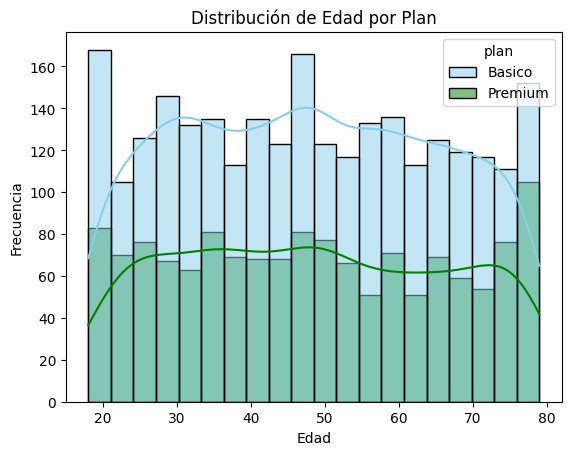

In [31]:
# Histograma para visualizar la edad (age)
sns.histplot(
    data=user_profile,
    x='age',
    hue='plan',
    palette=['skyblue','green'],
    bins=20,
    kde=True
)

plt.title('Distribución de Edad por Plan')
plt.xlabel('Edad')
plt.ylabel('Frecuencia')
plt.show()

La distribución de edad es bastante uniforme entre los 18 y 79 años, sin concentraciones extremas en un rango específico. Ambos planes presentan patrones muy similares, lo que sugiere que la edad no es un factor diferenciador fuerte entre usuarios Básico y Premium.

La forma de la distribución es aproximadamente simétrica, sin sesgo evidente hacia edades jóvenes o mayores. No se observan outliers marcados en esta variable.


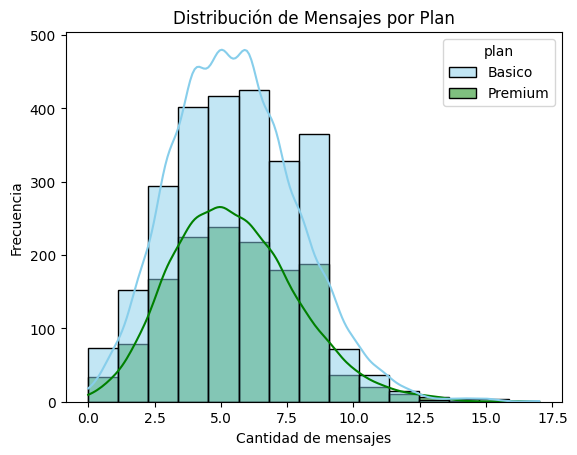

In [32]:
# Histograma para visualizar la cant_mensajes
sns.histplot(
    data=user_profile,
    x='cant_mensajes',
    hue='plan',
    palette=['skyblue','green'],
    bins=15,
    kde=True
)

plt.title('Distribución de Mensajes por Plan')
plt.xlabel('Cantidad de mensajes')
plt.ylabel('Frecuencia')
plt.show()


La distribución de mensajes presenta un sesgo a la derecha, ya que la mayoría de los usuarios envía entre 3 y 7 mensajes, mientras que pocos usuarios concentran valores altos (cola hacia la derecha).

Se observa que los usuarios del plan Básico muestran una ligera mayor concentración en rangos medios de mensajes, mientras que Premium presenta una distribución similar pero ligeramente más compacta. No se identifican diferencias extremas entre planes, aunque sí existen algunos usuarios con uso elevado que podrían considerarse outliers.


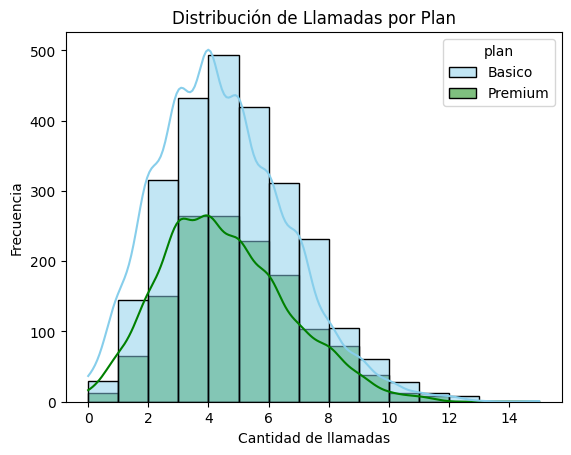

In [33]:
# Histograma para visualizar la cant_llamadas
sns.histplot(
    data=user_profile,
    x='cant_llamadas',
    hue='plan',
    palette=['skyblue','green'],
    bins=15,
    kde=True
)

plt.title('Distribución de Llamadas por Plan')
plt.xlabel('Cantidad de llamadas')
plt.ylabel('Frecuencia')
plt.show()


La mayor concentración de usuarios se encuentra entre 3 y 5 llamadas, lo que indica un patrón de uso relativamente moderado en ambos planes. A diferencia de los mensajes, la dispersión es ligeramente menor, sugiriendo un comportamiento más consistente en la cantidad de llamadas realizadas.

El plan Premium muestra una curva ligeramente más concentrada en valores medios, mientras que en Básico se aprecia una mayor presencia de usuarios con llamadas altas (cola más extendida). La distribución es claramente sesgada a la derecha, lo que indica que pocos usuarios realizan muchas llamadas.


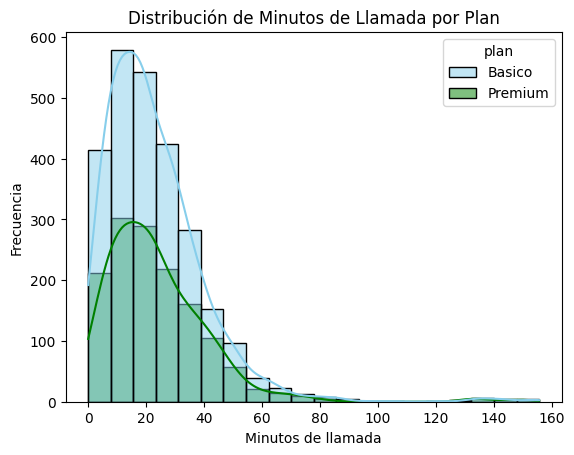

In [34]:
# Histograma para visualizar la cant_minutos_llamada
sns.histplot(
    data=user_profile,
    x='cant_minutos_llamada',
    hue='plan',
    palette=['skyblue','green'],
    bins=20,
    kde=True
)

plt.title('Distribución de Minutos de Llamada por Plan')
plt.xlabel('Minutos de llamada')
plt.ylabel('Frecuencia')
plt.show()


La distribución de minutos de llamada presenta un fuerte sesgo a la derecha, donde la mayoría de los usuarios consume entre 5 y 30 minutos, mientras que existe una cola larga con pocos usuarios que superan ampliamente los 60 minutos, alcanzando incluso valores cercanos a 150 minutos.

Se observa mayor dispersión en el plan Básico, donde aparecen los valores más extremos, mientras que Premium muestra una distribución ligeramente más concentrada en rangos medios. Esto sugiere la presencia de heavy users, especialmente en Básico, que podrían representar oportunidades de migración hacia planes superiores.

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

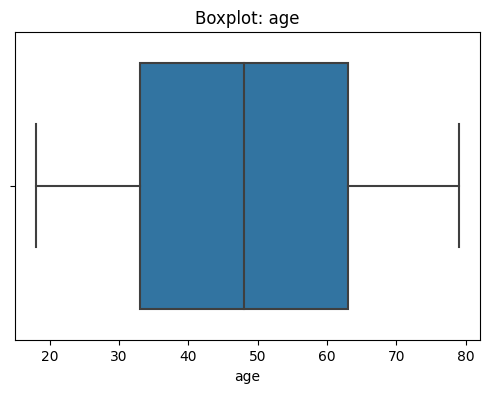

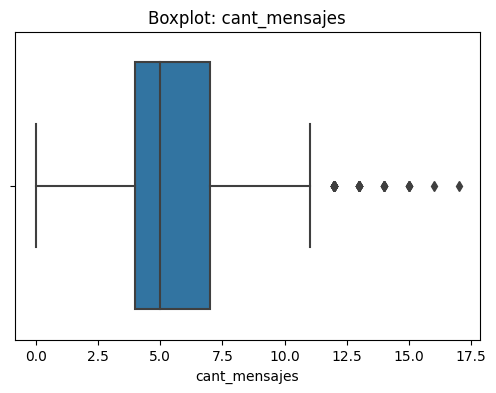

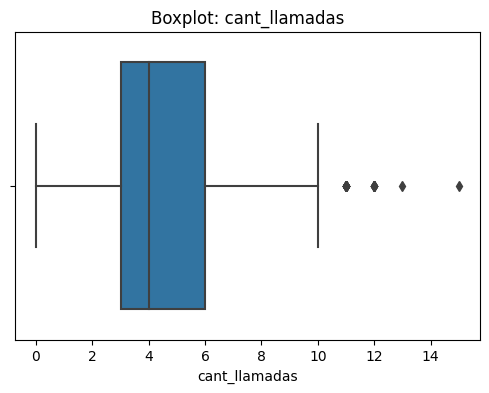

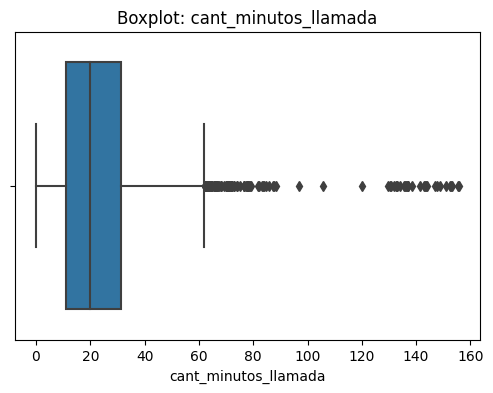

In [35]:
# Visualizando usando BoxPlot 

columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:
    plt.figure(figsize=(6,4))
    sns.boxplot(data=user_profile, x=col)
    plt.title(f'Boxplot: {col}')
    plt.show()

💡Insights: 
- Age: No presenta outliers relevantes. La distribución se encuentra dentro de un rango natural (18–79 años) y no muestra valores extremos fuera de los límites esperados.
- cant_mensajes: Presenta algunos outliers superiores (usuarios que envían muchos más mensajes que la mayoría), aunque no son extremadamente dispersos. La mayoría de los usuarios se concentra en un rango bajo–medio.
- cant_llamadas: También muestra outliers en la parte superior, pero en menor cantidad que minutos. Existen usuarios con un número de llamadas mayor al típico, aunque no de forma masiva.
- cant_minutos_llamada: Es la variable con mayor presencia de outliers. Se observa una cola larga hacia la derecha con múltiples valores extremos, lo que indica la existencia clara de heavy users que concentran un consumo significativamente superior al promedio.

In [39]:
# Calcular límites con el método IQR
columnas_limites = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_limites:
    Q1 = user_profile[col].quantile(0.25)
    Q3 = user_profile[col].quantile(0.75)
    IQR = Q3 - Q1
    
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR
    
    print(f"\nColumna: {col}")
    print(f"Límite inferior: {limite_inferior}")
    print(f"Límite superior: {limite_superior}")


Columna: age
Límite inferior: -12.0
Límite superior: 108.0

Columna: cant_mensajes
Límite inferior: -0.5
Límite superior: 11.5

Columna: cant_llamadas
Límite inferior: -1.5
Límite superior: 10.5

Columna: cant_minutos_llamada
Límite inferior: -19.322500000000005
Límite superior: 61.8575


In [38]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.000000,3999.000000,3999.000000,3999.000000
mean,48.136000,5.524381,4.478120,23.317054
std,17.689919,2.358416,2.144238,18.168095
min,18.000000,0.000000,0.000000,0.000000
25%,33.000000,4.000000,3.000000,11.120000
50%,48.000000,5.000000,4.000000,19.780000
75%,63.000000,7.000000,6.000000,31.415000
max,79.000000,17.000000,15.000000,155.690000


💡Insights: 
- cant_mensajes: El límite superior es 11.5, mientras que el máximo observado es 17. Existen algunos valores por encima del límite IQR, pero no son extremos desproporcionados. Se recomienda mantenerlos, ya que representan usuarios con mayor actividad y no errores.
- cant_llamadas: El límite superior es 10.5 y el máximo es 15. Aunque hay valores fuera del rango IQR, la diferencia no es exagerada y sigue siendo plausible dentro del comportamiento normal de uso. Se recomienda mantener los outliers.
- cant_minutos_llamada: El límite superior es 61.86, mientras que el máximo alcanza 155.69, lo que indica una desviación considerable. Sin embargo, estos valores corresponden a heavy users reales en telecomunicaciones. Se recomienda mantenerlos, ya que pueden ser estratégicamente relevantes para segmentación y análisis comercial.

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [41]:
# Crear columna grupo_uso
import numpy as np

# Condiciones
condiciones = [
    (user_profile['cant_llamadas'] < 5) & (user_profile['cant_mensajes'] < 5),
    (user_profile['cant_llamadas'] < 10) & (user_profile['cant_mensajes'] < 10)
]

# Etiquetas
grupos = ['Bajo uso', 'Uso medio']

# Crear columna
user_profile['grupo_uso'] = np.select(condiciones, grupos, default='Alto uso')

In [44]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso


In [45]:
# distribución de la segmentación:
user_profile['grupo_uso'].value_counts(normalize=True) * 100

Uso medio    73.575
Bajo uso     19.450
Alto uso      6.975
Name: grupo_uso, dtype: float64

In [47]:
# distribución de la segmentación según tipo de plan:
pd.crosstab(user_profile['plan'], user_profile['grupo_uso'], normalize='index') * 100

grupo_uso,Alto uso,Bajo uso,Uso medio
plan,,,
Basico,7.167630,19.730250,73.102119
Premium,6.619217,18.932384,74.448399


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [48]:
# Crear columna grupo_edad
import numpy as np

condiciones_edad = [
    (user_profile['age'] < 30),
    (user_profile['age'] < 60)
]

grupos_edad = ['Joven', 'Adulto']

user_profile['grupo_edad'] = np.select(
    condiciones_edad,
    grupos_edad,
    default='Adulto Mayor'
)

In [50]:
# verificar cambios
user_profile[['age', 'grupo_edad']].head()

,age,grupo_edad
0,38.0,Adulto
1,53.0,Adulto
2,57.0,Adulto
3,69.0,Adulto Mayor
4,63.0,Adulto Mayor


In [52]:
# Porcentaje según edad
user_profile['grupo_edad'].value_counts(normalize=True) * 100

Adulto          50.45
Adulto Mayor    30.55
Joven           19.00
Name: grupo_edad, dtype: float64

In [54]:
# Porcentaje de uso según grupos de edades
pd.crosstab(user_profile['grupo_edad'],
            user_profile['grupo_uso'],
            normalize='index') * 100

grupo_uso,Alto uso,Bajo uso,Uso medio
grupo_edad,,,
Adulto,7.631318,18.037661,74.331021
Adulto Mayor,6.055646,21.031097,72.913257
Joven,6.710526,20.657895,72.631579


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

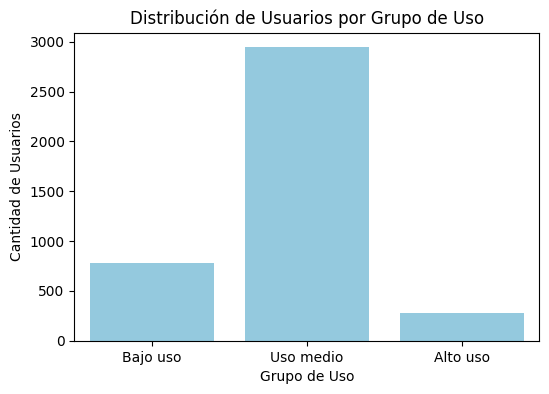

In [58]:
# Visualización de los segmentos por uso


plt.figure(figsize=(6,4))
sns.countplot(
    data=user_profile,
    x='grupo_uso',
    order=['Bajo uso','Uso medio','Alto uso'],
    color='skyblue'   # <- usa color en vez de palette
)
plt.title('Distribución de Usuarios por Grupo de Uso')
plt.xlabel('Grupo de Uso')
plt.ylabel('Cantidad de Usuarios')
plt.show()

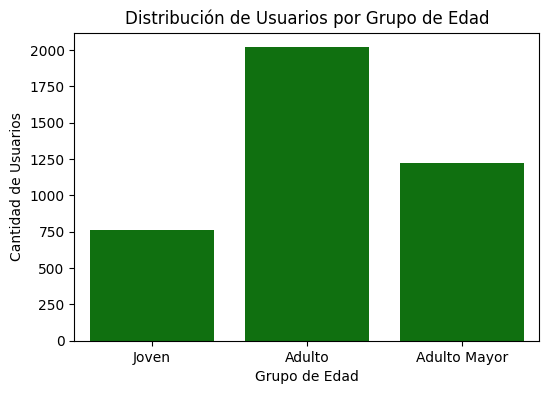

In [59]:
# Visualización de los segmentos por edad

plt.figure(figsize=(6,4))
sns.countplot(
    data=user_profile,
    x='grupo_edad',
    order=['Joven','Adulto','Adulto Mayor'],
    color='green'     # <- igual aquí
)
plt.title('Distribución de Usuarios por Grupo de Edad')
plt.xlabel('Grupo de Edad')
plt.ylabel('Cantidad de Usuarios')
plt.show()


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?
- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?
- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?


**Problemas originales en los datos**
Durante la revisión inicial se identificaron los siguientes problemas de calidad:
	•	Valores sentinela en age (-999).
	•	Fechas futuras en reg_date (año 2026).
	•	Valores inconsistentes en city (”?”).
	•	Nulos estructurales en duration y length, que dependían del tipo de registro (call vs text).

Los valores sentinela representaban un porcentaje bajo del total, mientras que los nulos en duration y length eran estructurales (esperados según el tipo de uso), por lo que no afectaban el análisis.

Tras la limpieza y estandarización, los datos quedaron consistentes y listos para análisis.

**Segmentos identificados y comportamiento**

Segmentación por nivel de uso
	•	Uso medio → 73.6%
	•	Bajo uso → 19.5%
	•	Alto uso → 7.0%

La mayoría de los usuarios presenta un consumo moderado, con un segmento pequeño pero relevante de alto consumo.

Segmentación por edad
	•	Adultos (30–59 años) → 50.4%
	•	Adulto Mayor (60+) → 30.6%
	•	Jóvenes (<30) → 19.0%

La base está compuesta principalmente por adultos en edad productiva.

Cruce edad vs uso

No se observaron diferencias fuertes entre grupos etarios en términos de intensidad de uso.
Todos mantienen una estructura similar: predominio de uso medio y una proporción reducida de alto uso.

La edad no parece ser un factor determinante en el nivel de consumo.

**Segmentos más valiosos**

El segmento de Alto uso (7%) es el más estratégico:
	•	Mayor consumo de minutos y mensajes.
	•	Potencial mayor ingreso promedio por usuario.
	•	Oportunidad clara de fidelización y planes premium.

El segmento Uso medio (74%) representa el núcleo del negocio y debe mantenerse satisfecho para evitar migración o churn.

**Patrones de uso extremo (Outliers)**

Se identificaron outliers principalmente en:
	•	Cantidad de mensajes.
	•	Cantidad de llamadas.
	•	Minutos de llamada.

Estos valores extremos están concentrados en el límite superior y representan usuarios con consumo significativamente mayor.

Dado que estos comportamientos pueden ser reales (usuarios intensivos), no se eliminaron, ya que aportan valor para entender el segmento premium y oportunidades de monetización.

**Recomendaciones estratégicas**

Optimización de planes
	•	Evaluar si el plan Básico cubre adecuadamente a los usuarios de uso medio.
	•	Crear un plan intermedio atractivo para incentivar upgrade.
	•	Diseñar beneficios adicionales para usuarios de alto uso (minutos extra, prioridad, beneficios digitales).

Estrategia comercial
	•	Campañas de upselling dirigidas a usuarios de uso medio cercanos al umbral de alto uso.
	•	Programas de retención para bajo uso (evitar churn).
	•	Incentivos especiales para fidelizar alto uso.

Segmentación futura

La segmentación por uso resulta más relevante que la segmentación por edad para decisiones comerciales.



### Análisis ejecutivo

**Problemas detectados en los datos**

	•Se identificaron valores sentinela en la edad (-999), fechas futuras en registros (2026) y valores inconsistentes en la ciudad (“?”), que requirieron limpieza.
	•Se detectaron valores nulos estructurales en duración y longitud de registros, dependientes del tipo de uso (llamada vs mensaje), los cuales fueron validados como esperados.

**Segmentos por Edad**

	•La base está compuesta principalmente por adultos (50%), seguida por adultos mayores (31%) y jóvenes (19%).
	•No se observaron diferencias significativas en el nivel de uso entre los distintos grupos etarios.

**Segmentos por Nivel de Uso**

	•El 74% de los usuarios presenta uso medio, 19% bajo uso y solo 7% alto uso.
	•El segmento de alto uso es reducido pero estratégico, ya que concentra el mayor consumo de servicios.

**Esto sugiere que:**

	•El principal driver de comportamiento no es la edad, sino la intensidad de uso.
	•Existe una oportunidad clara de monetización y fidelización en el segmento de alto uso.
	•La mayoría de la base se encuentra en un punto óptimo para estrategias de upselling.

**Recomendaciones**

	•Diseñar estrategias de upgrade para usuarios de uso medio cercanos al umbral de alto uso.
	•Crear beneficios diferenciados para retener y maximizar el valor del segmento de alto consumo.
	•Implementar campañas de activación para reducir el porcentaje de bajo uso y prevenir churn.

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`